# Palantir Sample Dataset — scJDO Drift Field Analysis (LDVAE)

Same pipeline as `Palantir_sample_notebook_driftfield.ipynb`, but using
**LinearSCVI (LDVAE)** — a VAE with a linear decoder — for the latent embedding.

| Step | PCA version | LDVAE version |
|---|---|---|
| Count model | Gaussian (log-norm) | **Negative binomial (raw counts)** |
| Encoder | PCA (linear) | **Nonlinear (handles dropout/noise)** |
| Decoder | PCA (linear) | **Linear (preserves bifurcation geometry)** |
| Latent space | `X_pca` | **`X_ldvae`** |
| Gene loadings | PCA loadings `varm["PCs"]` | **LDVAE decoder weights `varm["PCs"]`** |
| UMAP / neighbors | PCA-based | **LDVAE-based** |
| Palantir pseudotime | PCA manifold | **LDVAE manifold** |
| scJDO drift field | `X_pca` | **`X_ldvae`** |

**Why LDVAE (not standard scVI)?**  
Standard scVI's nonlinear decoder unfolds the data manifold, removing the
bifurcation saddle-point geometry that scJDO's Jacobian detector needs.
LDVAE's linear decoder preserves that geometry while still modelling counts
with a negative binomial likelihood and handling technical noise nonlinearly
in the encoder.

**Dataset:** `marrow_sample_scseq_counts.h5ad` — 4,142 cells, 16,106 genes  
**Lineages:** Erythroid (Ery), Dendritic Cell (DC), Monocyte (Mono)

In [12]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import palantir
import scjdo as sjd
from scjdo.tl._drift import _pseudotime_velocity

OUTDIR = 'results/palantir_driftfield_ldvae/'
os.makedirs(OUTDIR, exist_ok=True)

# ── Exact parameters from Palantir sample notebook ─────────────────────────
START_CELL      = 'Run5_164698952452459'
TERMINAL_STATES = pd.Series(
    ['DC',                   'Mono',                  'Ery'],
    index=['Run5_131097901611291', 'Run5_134936662236454', 'Run4_200562869397916']
)
N_WAYPOINTS     = 500

# ── LDVAE config ───────────────────────────────────────────────────────────
N_LATENT        = 20    # latent dimensions
N_LDVAE_EPOCHS  = 400   # increase to 800 for better convergence
N_HVG           = 1500

# ── scJDO config ─────────────────────────────────────────────────────────
N_ARCHETYPES    = 5
N_EPOCHS        = 5000   # increase to 50000 on GPU for publication quality
SEED            = 42

# ── Biology-informed velocity bias ─────────────────────────────────────────
BIAS_STRENGTH   = 1.5

print(f'scjdo  v{sjd.__version__}')
print(f'palantir v{palantir.__version__}')
print(f'Latent: LDVAE ({N_LATENT}-D)  |  Pseudotime: Palantir  |  Branches: separated')

scjdo  v0.3.0
palantir v1.4.4
Latent: LDVAE (20-D)  |  Pseudotime: Palantir  |  Branches: separated


## Step 1 — Reproduce Palantir preprocessing

Exact steps from `Palantir_sample_notebook.ipynb`.

In [13]:
# Load raw data
ad = sc.read(os.path.join('./', 'marrow_sample_scseq_counts.h5ad'))
print(f'Loaded: {ad.n_obs} cells x {ad.n_vars} genes')

# Store raw counts before normalization (LDVAE needs these for NB likelihood)
ad.layers['raw_counts'] = ad.X.copy()

# Normalize + log (Palantir uses pseudocount=0.1)
sc.pp.normalize_per_cell(ad)
palantir.preprocess.log_transform(ad)

# ── HVG selection + subsetting ────────────────────────────────────────────
sc.pp.highly_variable_genes(ad, n_top_genes=N_HVG, flavor='cell_ranger')
ad._inplace_subset_var(ad.var.highly_variable)
print(f'After HVG filter: {ad.n_obs} cells x {ad.n_vars} genes')

# ── LinearSCVI (LDVAE) ────────────────────────────────────────────────────
# Linear decoder: x = W @ z + b  (preserves bifurcation saddle geometry)
# Nonlinear encoder: better count modelling than PCA (NB likelihood, dropout)
import scvi
scvi.settings.seed = SEED
scvi.model.LinearSCVI.setup_anndata(ad, layer='raw_counts')
model = scvi.model.LinearSCVI(ad, n_latent=N_LATENT)
model.train(max_epochs=N_LDVAE_EPOCHS, plan_kwargs={'lr': 1e-3},
            early_stopping=True, early_stopping_patience=20)

ad.obsm['X_ldvae'] = model.get_latent_representation()
print(f'LDVAE latent: {ad.obsm["X_ldvae"].shape}')

# Gene loadings from linear decoder — direct analog of PCA loadings.
# Shape (n_genes, n_latent): used by scJDO for gene instability scoring.
loadings = model.get_loadings()          # DataFrame indexed by gene names
ad.varm['PCs'] = loadings.loc[ad.var_names].values
print(f'LDVAE loadings: {ad.varm["PCs"].shape}  (drop-in for varm["PCs"])')

# ── Diffusion maps on LDVAE manifold ──────────────────────────────────────
# Palantir reads obsm['X_pca'] — temporarily swap so DMs are built on LDVAE.
ad.obsm['X_pca'] = ad.obsm['X_ldvae']
dm_res  = palantir.utils.run_diffusion_maps(ad, n_components=10)
ms_data = palantir.utils.determine_multiscale_space(ad)
del ad.obsm['X_pca']   # remove temporary; X_ldvae is the canonical rep
print('Diffusion maps: built on LDVAE space')

# ── UMAP + neighbors on LDVAE space ───────────────────────────────────────
sc.pp.neighbors(ad, use_rep='X_ldvae', n_neighbors=30)
sc.tl.umap(ad)

# ── MAGIC imputation (needed for gene trend visualization) ─────────────────
palantir.utils.run_magic_imputation(ad)

# Tell scJDO to use LDVAE for drift field and gene scoring
ad.uns['scjdo_prep'] = {'latent': 'ldvae', 'rep': 'X_ldvae'}

print('Preprocessing complete.')
print(f'obsm keys: {list(ad.obsm.keys())}')

Loaded: 4142 cells x 16106 genes


Seed set to 42


After HVG filter: 4142 cells x 1500 genes


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


LDVAE latent: (4142, 20)
LDVAE loadings: (1500, 20)  (drop-in for varm["PCs"])
Diffusion maps: built on LDVAE space
Preprocessing complete.
obsm keys: ['X_ldvae', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_umap']


## Step 2 — Run Palantir (identical to sample notebook)

In [14]:
# Run Palantir with known terminal states
pr_res = palantir.core.run_palantir(
    ad,
    START_CELL,
    num_waypoints   = N_WAYPOINTS,
    terminal_states = TERMINAL_STATES,
)
# Stored automatically:
#   ad.obs['palantir_pseudotime']       [0, 1]
#   ad.obs['palantir_entropy']
#   ad.obsm['palantir_fate_probabilities']  (DC, Mono, Ery)

print('Palantir results:')
print(f'  Pseudotime range: [{ad.obs["palantir_pseudotime"].min():.3f}, '
      f'{ad.obs["palantir_pseudotime"].max():.3f}]')
print(f'  Fate prob columns: {list(ad.obsm["palantir_fate_probabilities"].columns)}')

Sampling and flocking waypoints...
Time for determining waypoints: 7.478793462117513e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.016403583685557048 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9997
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Palantir results:
  Pseudotime range: [0.000, 1.000]
  Fate prob columns: ['Ery', 'DC', 'Mono']


Branch cell counts:
  Ery: 1404 cells (34%)
  DC: 1898 cells (46%)
  Mono: 1929 cells (47%)

Cell fate labels (used for velocity bias):
cell_fate
Mono          2648
Progenitor    1036
Ery            383
DC              75


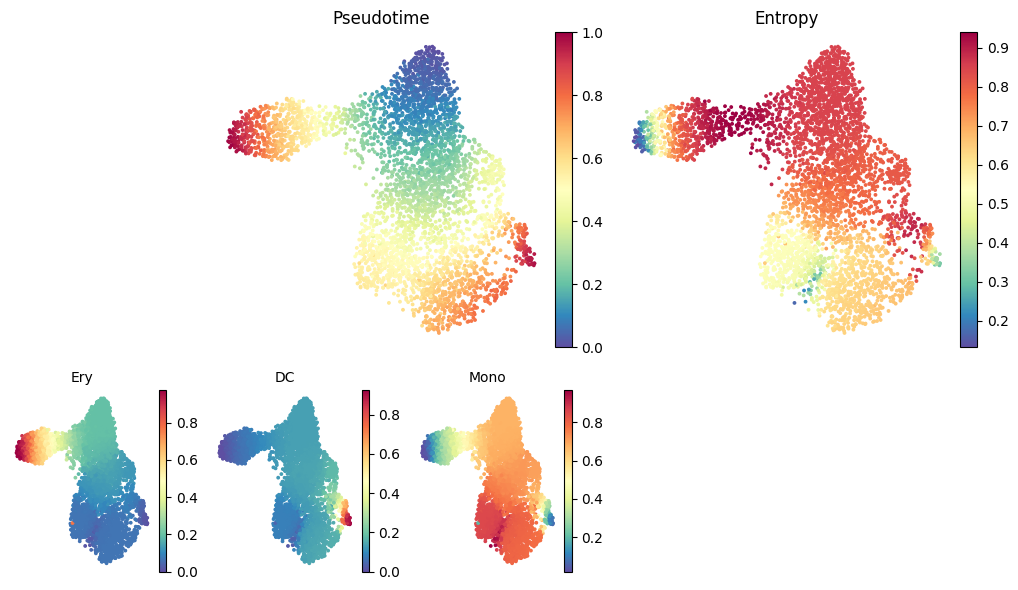

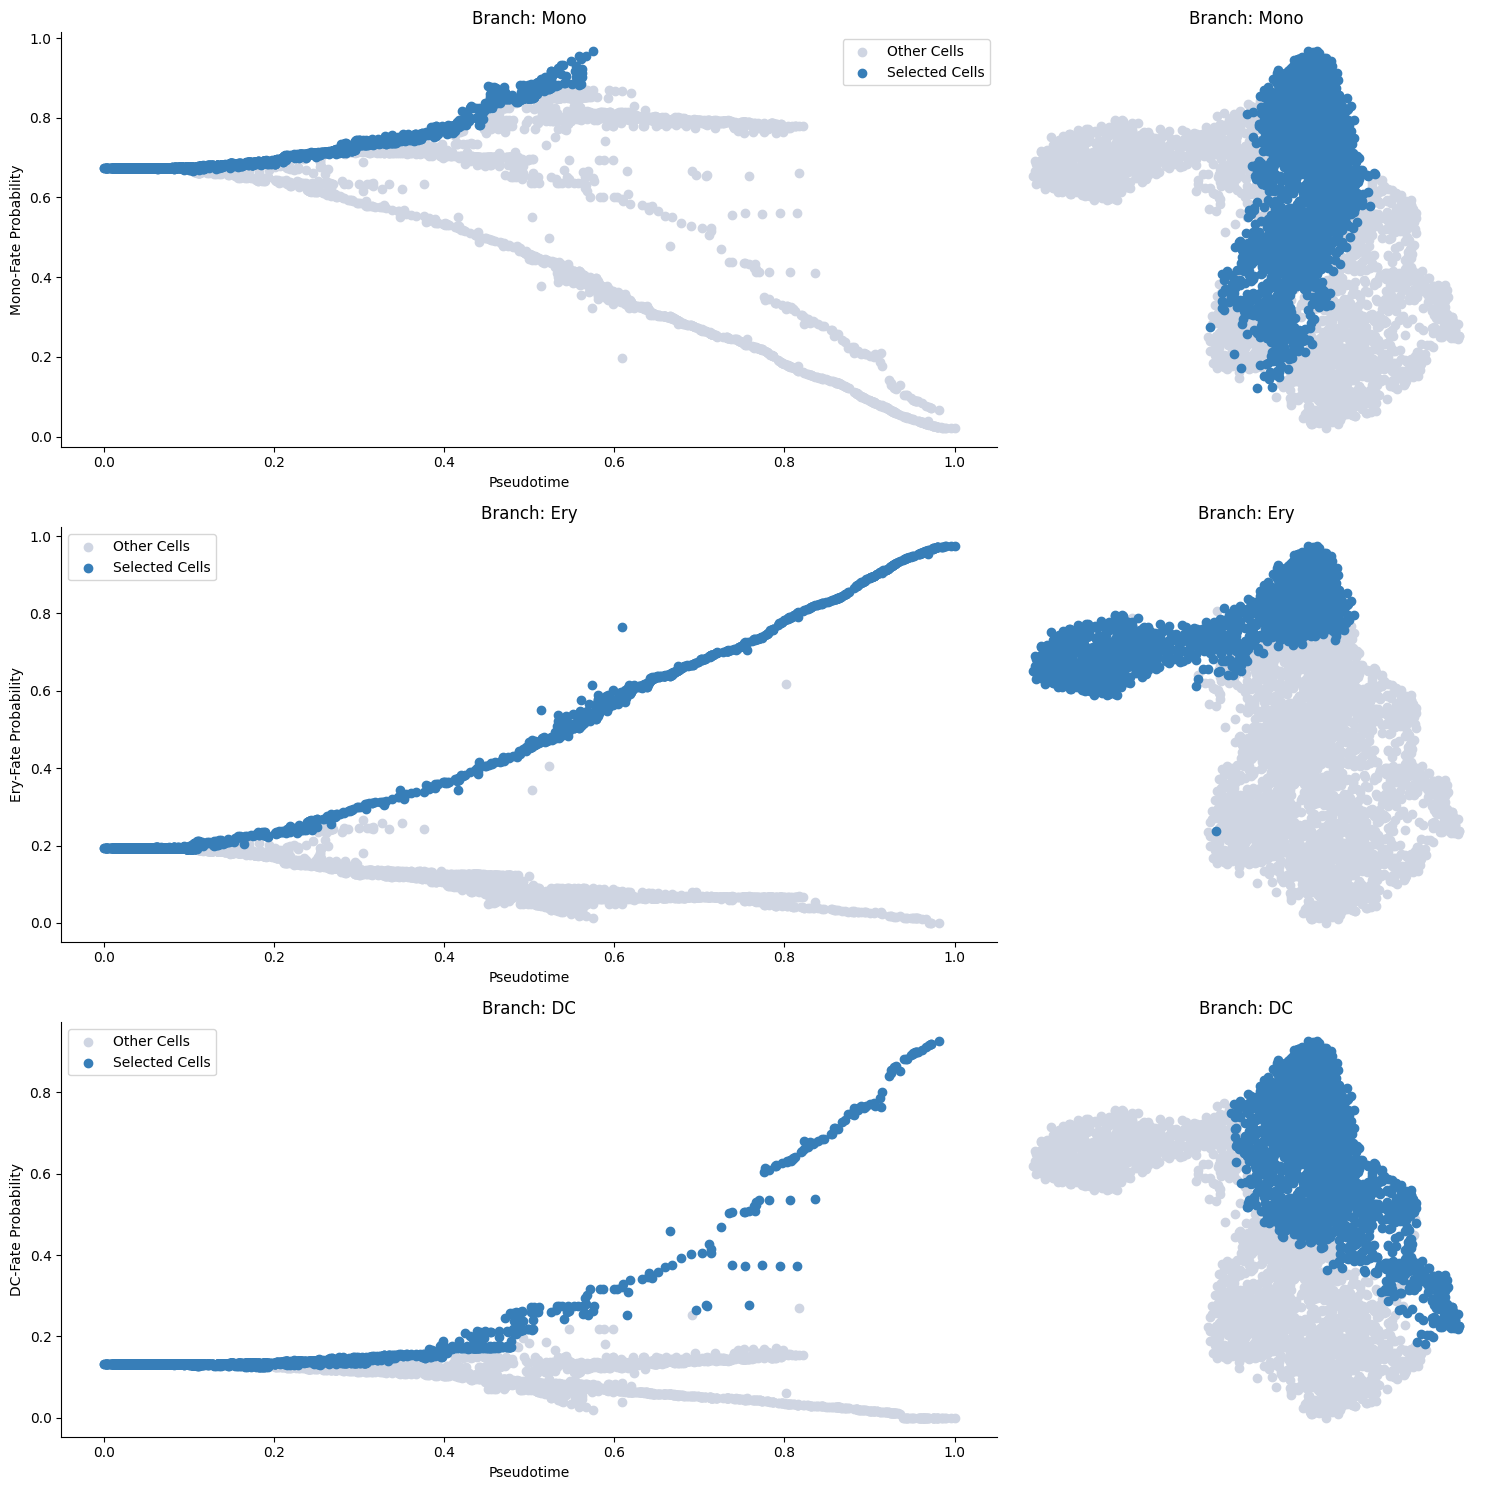

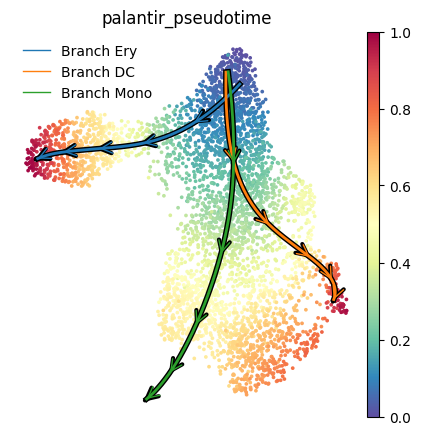

[2026-05-25 21:11:22,182] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,404) and rank = 1.0.
[2026-05-25 21:11:22,183] [INFO    ] Using covariance function Matern52(ls=0.9697796702384949).
[2026-05-25 21:11:22,183] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-25 21:11:22,190] [INFO    ] Sigma interpreted as element-wise standard deviation.


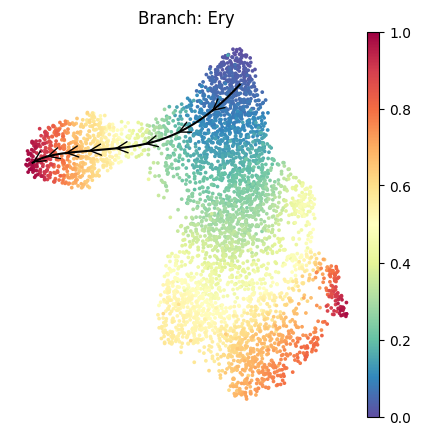

[2026-05-25 21:11:22,354] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,898) and rank = 1.0.
[2026-05-25 21:11:22,355] [INFO    ] Using covariance function Matern52(ls=0.9697796702384949).
[2026-05-25 21:11:22,355] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-25 21:11:22,363] [INFO    ] Sigma interpreted as element-wise standard deviation.


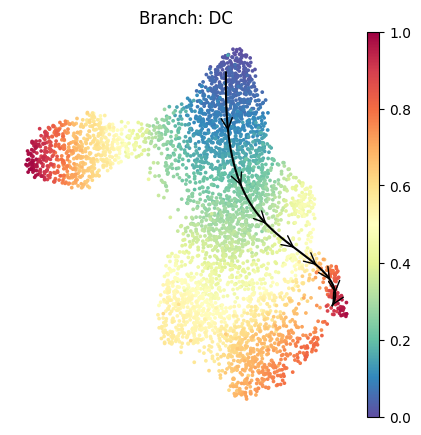

[2026-05-25 21:11:22,530] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,929) and rank = 1.0.
[2026-05-25 21:11:22,531] [INFO    ] Using covariance function Matern52(ls=0.9697796702384949).
[2026-05-25 21:11:22,531] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-25 21:11:22,540] [INFO    ] Sigma interpreted as element-wise standard deviation.


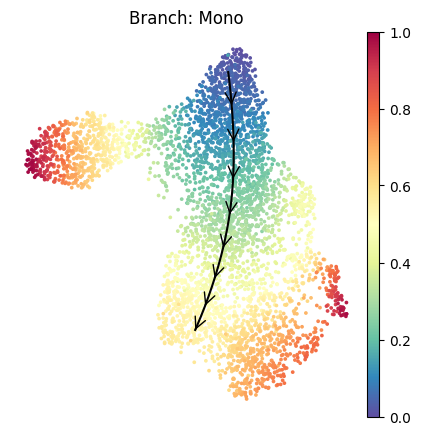

In [15]:
# ── select_branch_cells ─────────────────────────────────────────────────────
palantir.presults.select_branch_cells(ad, q=0.01, eps=0.01,
                                       masks_key='branch_masks', save_as_df=True)
masks_df = ad.obsm['branch_masks']
print('Branch cell counts:')
for col in masks_df.columns:
    n = masks_df[col].sum()
    print(f'  {col}: {n} cells ({100*n/len(ad):.0f}%)')

# ── Create cell_fate label for biology-informed bias ─────────────────────────
# Each cell is assigned to its dominant Palantir fate.
# High-entropy cells (top 25%) are labelled 'Progenitor' — these are the
# undifferentiated stem/progenitor cells that precede all lineages.
fate_probs = ad.obsm['palantir_fate_probabilities']
ad.obs['cell_fate'] = fate_probs.idxmax(axis=1).astype(str)

entropy_threshold = ad.obs['palantir_entropy'].quantile(0.75)
ad.obs.loc[ad.obs['palantir_entropy'] >= entropy_threshold, 'cell_fate'] = 'Progenitor'

print('\nCell fate labels (used for velocity bias):')
print(ad.obs['cell_fate'].value_counts().to_string())

# ── Palantir visualizations ──────────────────────────────────────────────────
palantir.plot.plot_palantir_results(ad, s=3)
plt.savefig(OUTDIR + 'palantir_results.pdf', dpi=150, bbox_inches='tight')
plt.show()

palantir.plot.plot_branch_selection(ad)
plt.savefig(OUTDIR + 'branch_selection.pdf', dpi=150, bbox_inches='tight')
plt.show()

palantir.plot.plot_trajectories(ad, pseudotime_interval=(0, 0.95))
plt.savefig(OUTDIR + 'trajectories.pdf', dpi=150, bbox_inches='tight')
plt.show()

for branch in ad.obsm['branch_masks'].columns:
    palantir.plot.plot_trajectory(ad, branch,
                                   cell_color='palantir_pseudotime', n_arrows=8)
    plt.savefig(OUTDIR + f'trajectory_{branch}.pdf', dpi=150, bbox_inches='tight')
    plt.show()

## Step 3 — scJDO branch-separated drift field analysis

Run scJDO independently on each Palantir branch (Ery, DC, Mono).
Each branch uses only its own cells — no cross-lineage Jacobian mixing.
The branch masks from Palantir include shared progenitors (correct biologically).

In [16]:
# Reload scjdo modules to pick up any code changes without restarting kernel
import importlib
import scjdo.tl._drift as _drift_mod
importlib.reload(_drift_mod)
import scjdo.tl as tl_mod
importlib.reload(tl_mod)
import scjdo
importlib.reload(scjdo)
import scjdo as sjd
print(f'scjdo reloaded — fit_drift_branches has bias params: '
      f'{"bias_strength" in str(__import__("inspect").signature(sjd.tl.fit_drift_branches))}')

scjdo reloaded — fit_drift_branches has bias params: True


In [17]:
# ── scJDO branch-separated with biology-informed velocity bias ─────────────
#
# The bias uses Palantir's own outputs as prior knowledge:
#   - 'Progenitor' label (high entropy)  → progenitor centroid
#   - 'DC', 'Mono', 'Ery' labels (dominant fate) → terminal centroids
#
# For each branch the velocity prior is:
#   V = pseudotime_gradient + BIAS_STRENGTH × pull_toward_terminal
# where pull_toward_terminal[i] = normalize(X_terminal - X[i]) × pseudotime[i]
# Cells projected onto the progenitor→terminal axis so lateral drift is suppressed.

branch_models = sjd.tl.fit_drift_branches(
    ad,
    branch_key         = 'branch_masks',
    branch_names       = list(ad.obsm['branch_masks'].columns),
    time_key           = 'palantir_pseudotime',
    # Biology-informed bias — derived from Palantir fate probabilities
    groupby            = 'cell_fate',      # column we just created above
    progenitor_cluster = 'Progenitor',     # high-entropy undifferentiated cells
    terminal_clusters  = {                 # dominant-fate cells per lineage
        'DC':   'DC',
        'Mono': 'Mono',
        'Ery':  'Ery',
    },
    bias_strength      = BIAS_STRENGTH,
    n_archetypes       = N_ARCHETYPES,
    n_epochs           = N_EPOCHS,
    vel_scale          = 2.0,
    seed               = SEED,
)

print('\nBranch results summary:')
for name in branch_models:
    key   = f'scjdo_{name}'
    r2    = ad.uns[key]['r2']
    n     = ad.uns[key]['n_cells']
    peak  = ad.uns[key]['t_centers'][np.argmax(ad.uns[key]['max_real_eig'])]
    print(f'  {name:6s}: {n:4d} cells | R2={r2:.3f} | '
          f'peak sensitivity at t={peak:.3f}')

[bias] Progenitor 'Progenitor': 1036 cells, centroid computed in X_ldvae

Branch: Ery  (1404 cells)
  [bias] Terminal 'Ery': 383 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: 0.270
[fit_drift] Using representation: X_ldvae (latent=ldvae)
Computing pseudotime-gradient velocity prior...
DriftField: 871,592 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 69.5750
Computing Jacobian tensor...


Jacobians:   0%|          | 0/100 [00:00<?, ?it/s]

Running archetype decomposition (semi-NMF)...
Done. R²=0.983 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.983  stored in adata.uns['scjdo_Ery']

Branch: DC  (1898 cells)
  [bias] Terminal 'DC': 75 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: 0.372
[fit_drift] Using representation: X_ldvae (latent=ldvae)
Computing pseudotime-gradient velocity prior...
DriftField: 871,592 parameters | device=cpu | epochs=5000


...

Running archetype decomposition (semi-NMF)...
Done. R²=0.976 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.976  stored in adata.uns['scjdo_DC']

Branch: Mono  (1929 cells)
  [bias] Terminal 'Mono': 2648 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: 0.212
[fit_drift] Using representation: X_ldvae (latent=ldvae)
Computing pseudotime-gradient velocity prior...
DriftField: 871,592 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 77.8057
Computing Jacobian tensor...


Jacobians:   0%|          | 0/100 [00:00<?, ?it/s]

Running archetype decomposition (semi-NMF)...
Done. R²=0.998 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.998  stored in adata.uns['scjdo_Mono']

Branch results stored: ['scjdo_Ery', 'scjdo_DC', 'scjdo_Mono']

Branch results summary:
  Ery   : 1404 cells | R2=0.983 | peak sensitivity at t=0.764
  DC    : 1898 cells | R2=0.976 | peak sensitivity at t=0.947
  Mono  : 1929 cells | R2=0.998 | peak sensitivity at t=0.024


## Step 4 — Per-branch figures

For each lineage: drift field, local sensitivity, archetype profiles, coordination.


=== Ery lineage (1404 cells) ===


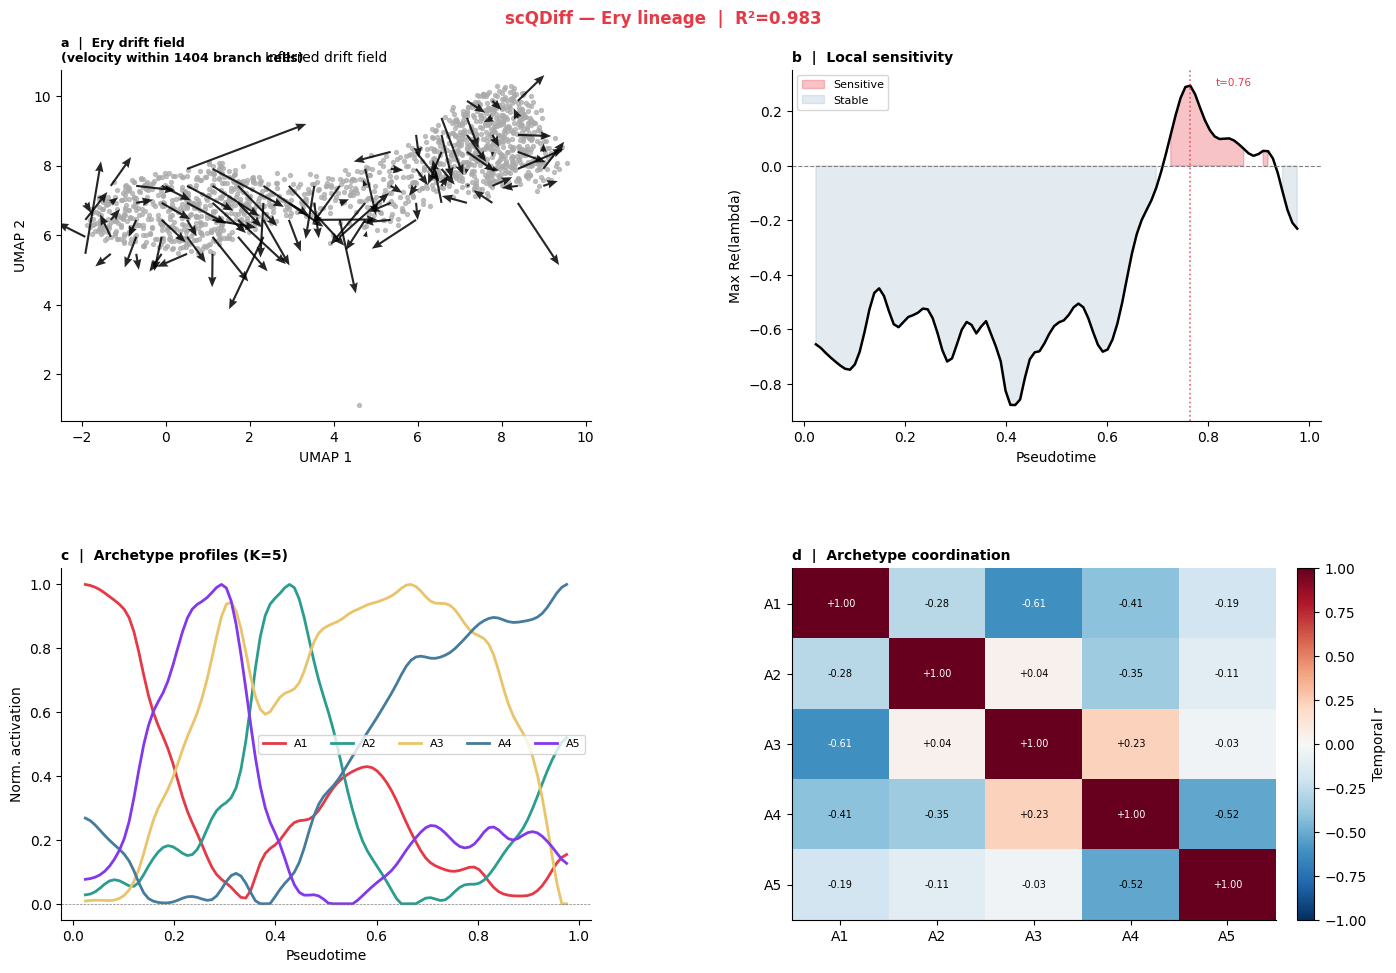

Saved: results/palantir_driftfield_ldvae/figure_Ery.pdf

=== DC lineage (1898 cells) ===


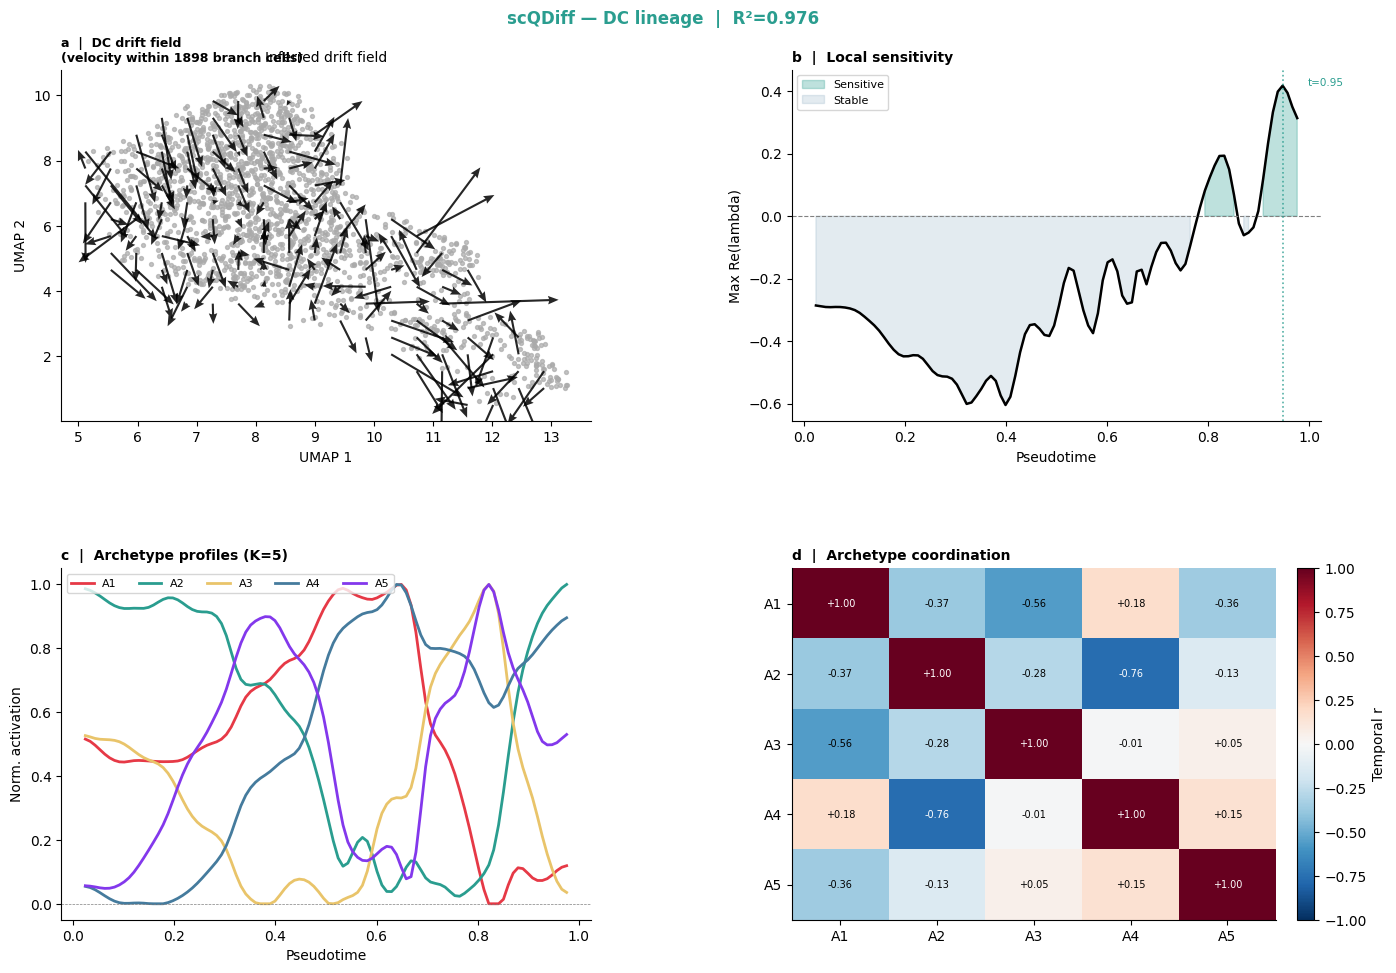

Saved: results/palantir_driftfield_ldvae/figure_DC.pdf

=== Mono lineage (1929 cells) ===


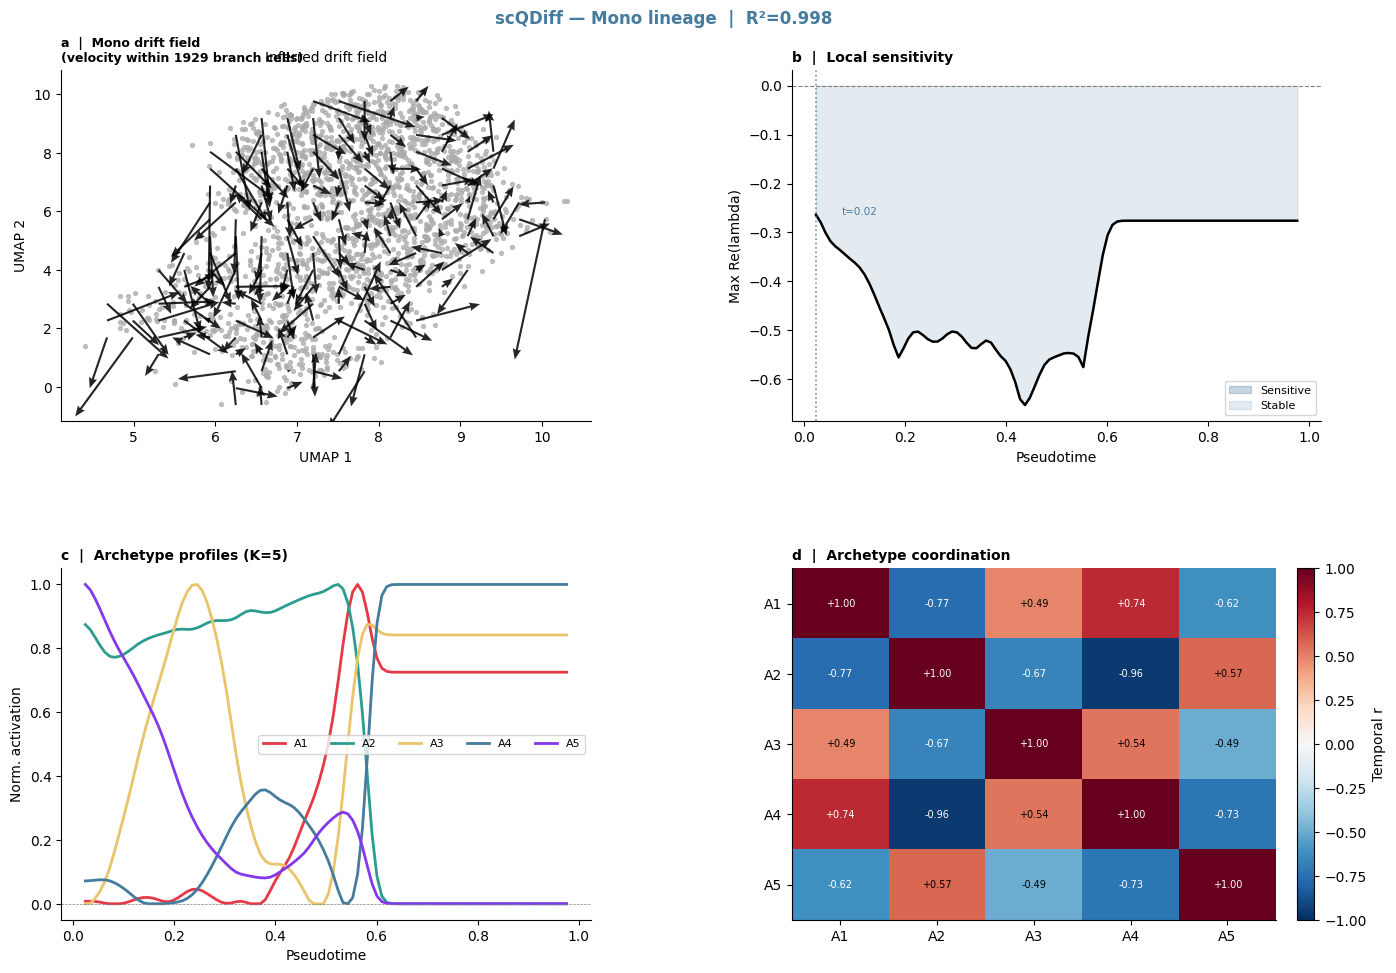

Saved: results/palantir_driftfield_ldvae/figure_Mono.pdf


In [18]:
BRANCH_COLORS = {'Ery': '#E63946', 'DC': '#2A9D8F', 'Mono': '#457B9D'}
ARCH_COLORS   = ['#E63946','#2A9D8F','#E9C46A','#457B9D','#8338EC']

for branch in branch_models:
    key      = f'scjdo_{branch}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    print(f'\n=== {branch} lineage ({len(cell_idx)} cells) ===')

    # Subset to branch cells
    ad_b = ad[cell_idx].copy()
    ad_b.uns[key] = ad.uns[key]

    # Compute branch-specific velocity (arrows point correctly along THIS lineage)
    X_branch  = ad_b.obsm['X_ldvae'].astype('float32')
    pt_branch = ad_b.obs['palantir_pseudotime'].values.astype('float32')
    V_branch  = _pseudotime_velocity(X_branch, pt_branch, k=15)
    ad_b.obsm['X_velocity_pseudo'] = V_branch
    if 'X_drift' in ad.uns[key]:
        ad_b.obsm['X_drift'] = ad.uns[key]['X_drift']

    res     = ad.uns[key]
    t_np    = res['t_centers']
    max_eig = res['max_real_eig']
    act     = res['act_norm']
    corr    = res['corr_mat']
    K       = act.shape[1]
    branch_col = BRANCH_COLORS.get(branch, '#555')

    # ── 4-panel manuscript figure ─────────────────────────────────────────
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.38,
                            left=0.07, right=0.97, top=0.92, bottom=0.07)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])

    # Panel a — drift field on UMAP (branch-specific velocity)
    sjd.pl.drift_field(
        ad_b, key=key,
        basis        = 'X_umap',
        color        = 'Pseudotime',
        velocity_key = 'X_velocity_pseudo',
        stream       = False,
        n_grid       = 18,
        min_cells    = 2,
        ax           = ax_a,
    )
    ax_a.set_title(f'a  |  {branch} drift field\n'
                   f'(velocity within {len(cell_idx)} branch cells)',
                   fontweight='bold', loc='left', fontsize=9)

    # Panel b — local sensitivity
    sens = max_eig >= 0.05
    ax_b.plot(t_np, max_eig, color='black', lw=1.8)
    ax_b.fill_between(t_np, max_eig, 0, where=sens,
                      alpha=0.30, color=branch_col, label='Sensitive')
    ax_b.fill_between(t_np, max_eig, 0, where=max_eig<=-0.05,
                      alpha=0.15, color='#457B9D', label='Stable')
    ax_b.axhline(0, color='gray', lw=0.8, ls='--')
    peak_t = t_np[np.argmax(max_eig)]
    ax_b.axvline(peak_t, color=branch_col, lw=1.2, ls=':', alpha=0.8)
    ax_b.annotate(f't={peak_t:.2f}', xy=(peak_t, max_eig.max()),
                  xytext=(peak_t+0.05, max_eig.max()),
                  fontsize=7.5, color=branch_col)
    ax_b.set_xlabel('Pseudotime'); ax_b.set_ylabel('Max Re(lambda)')
    ax_b.set_title('b  |  Local sensitivity',
                   fontweight='bold', loc='left', fontsize=10)
    ax_b.legend(fontsize=8)

    # Panel c — archetype activation profiles
    for k in range(K):
        ax_c.plot(t_np, act[:, k], color=ARCH_COLORS[k], lw=2, label=f'A{k+1}')
    ax_c.axhline(0, color='gray', lw=0.5, ls='--')
    ax_c.set_xlabel('Pseudotime'); ax_c.set_ylabel('Norm. activation')
    ax_c.set_title(f'c  |  Archetype profiles (K={K})',
                   fontweight='bold', loc='left', fontsize=10)
    ax_c.legend(ncol=K, fontsize=8)

    # Panel d — coordination heatmap
    im = ax_d.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax_d.set_xticks(range(K)); ax_d.set_xticklabels([f'A{k+1}' for k in range(K)])
    ax_d.set_yticks(range(K)); ax_d.set_yticklabels([f'A{k+1}' for k in range(K)])
    for i in range(K):
        for j in range(K):
            ax_d.text(j, i, f'{corr[i,j]:+.2f}', ha='center', va='center',
                      fontsize=7, color='white' if abs(corr[i,j])>0.6 else 'black')
    plt.colorbar(im, ax=ax_d, label='Temporal r', fraction=0.046, pad=0.04)
    ax_d.set_title('d  |  Archetype coordination',
                   fontweight='bold', loc='left', fontsize=10)

    fig.suptitle(f'scJDO — {branch} lineage  |  R²={res["r2"]:.3f}',
                 fontsize=12, fontweight='bold', color=branch_col)
    save_path = OUTDIR + f'figure_{branch}.pdf'
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved: {save_path}')

## Step 5 — Instability genes per lineage

Which genes drive dynamical sensitivity in each lineage?


Ery lineage — instability genes


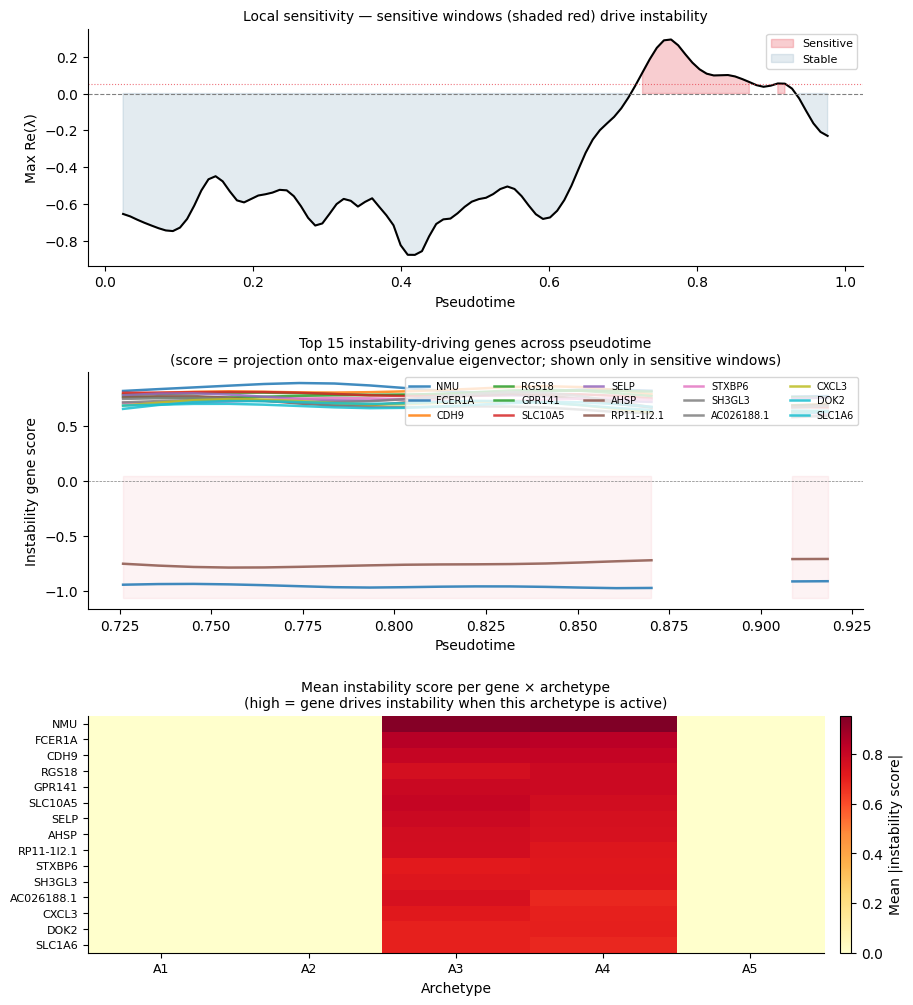

 rank       gene  mean_instability_score  peak_pseudotime primary_archetype
    1        NMU                  0.9487            0.861                A4
    2     FCER1A                  0.8262            0.774                A3
    3       CDH9                  0.7921            0.841                A4
    4      RGS18                  0.7861            0.851                A4
    5     GPR141                  0.7770            0.841                A4
    6    SLC10A5                  0.7643            0.755                A3
    7       SELP                  0.7600            0.745                A3
    8       AHSP                  0.7462            0.755                A3
    9 RP11-1I2.1                  0.7249            0.832                A4
   10     STXBP6                  0.7125            0.784                A3
   11     SH3GL3                  0.7064            0.832                A4
   12 AC026188.1                  0.6875            0.745                A3
   13      C

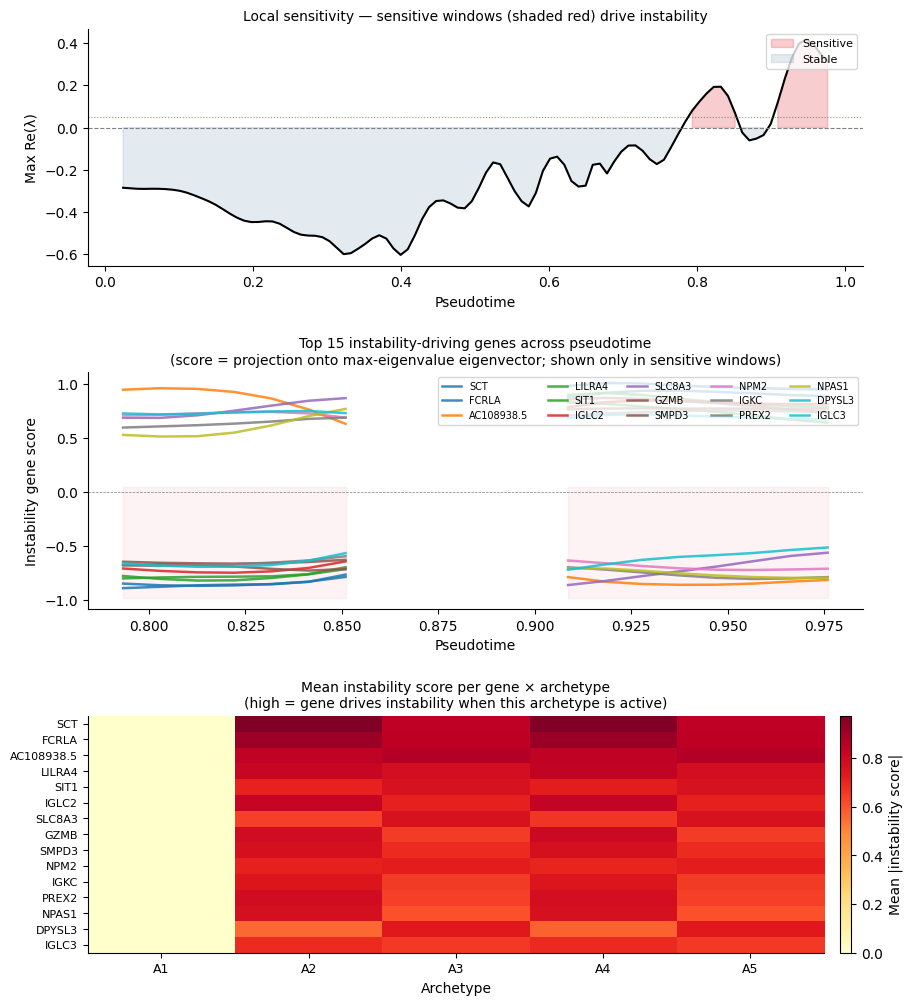

 rank       gene  mean_instability_score  peak_pseudotime primary_archetype
    1        SCT                  0.9084            0.918                A2
    2      FCRLA                  0.8766            0.938                A2
    3 AC108938.5                  0.8443            0.803                A3
    4     LILRA4                  0.8140            0.918                A2
    5       SIT1                  0.7638            0.909                A2
    6      IGLC2                  0.7606            0.928                A2
    7     SLC8A3                  0.7412            0.851                A5
    8       GZMB                  0.7350            0.918                A2
    9      SMPD3                  0.7313            0.928                A2
   10       NPM2                  0.7008            0.832                A3
   11       IGKC                  0.6972            0.947                A2
   12      PREX2                  0.6953            0.957                A2
   13      N

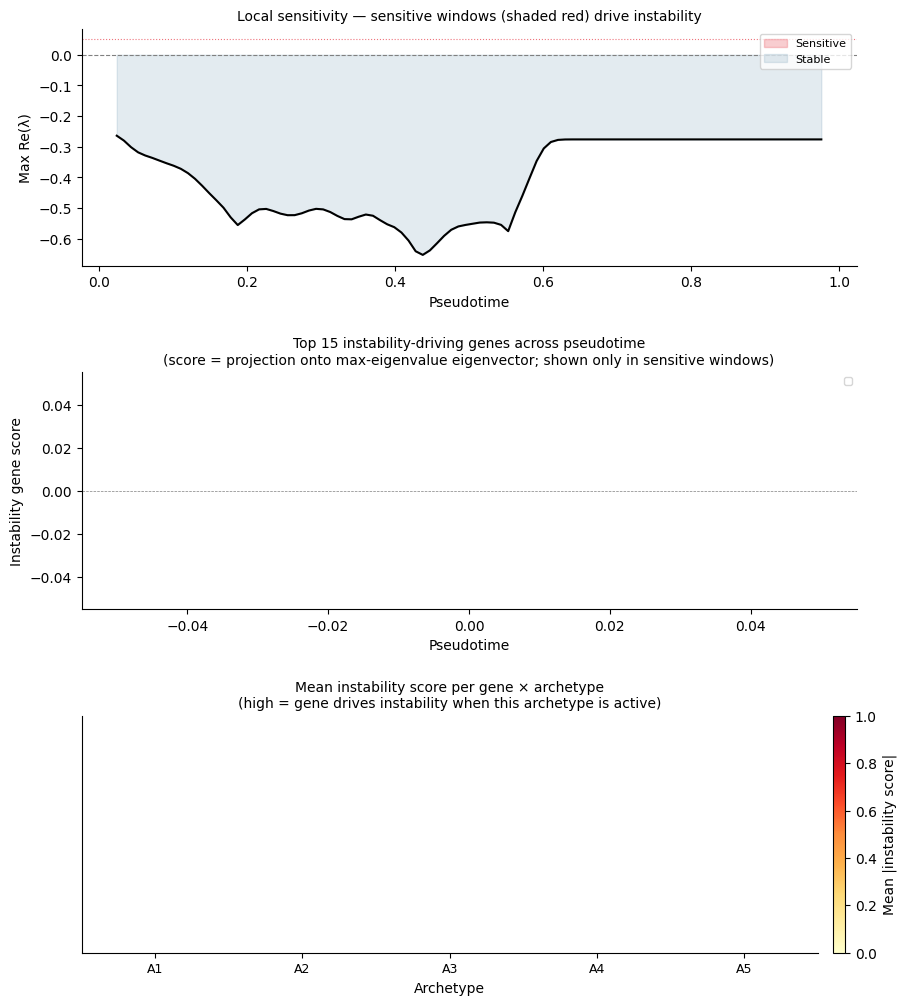

Empty DataFrame
Columns: []
Index: []


In [19]:
gene_tables = {}

for branch in branch_models:
    key      = f'scjdo_{branch}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    ad_b     = ad[cell_idx].copy()
    ad_b.uns[key]    = ad.uns[key]
    if 'PCs' in ad.varm:
        ad_b.varm['PCs'] = ad.varm['PCs']

    print(f'\n{"="*55}')
    print(f'{branch} lineage — instability genes')
    print(f'{"="*55}')
    table = sjd.pl.instability_genes(
        ad_b,
        key     = key,
        n_genes = 15,
        save    = OUTDIR + f'instability_genes_{branch}.pdf',
    )
    gene_tables[branch] = table
    table.to_csv(OUTDIR + f'instability_genes_{branch}.csv', index=False)

## Step 6 — Regulatory network per lineage

Which TFs drive instability in DC vs Mono vs Ery programs?


Ery lineage — regulators
[network] TRRUST v2 loaded — 9,396 edges
Found 10 regulators
regulator  weighted_score
    NFKB1         16.1326
     RELA         15.6302
      SP1         13.8880
    STAT3          6.8232
      JUN          5.9377
     E2F1          5.8088
    HDAC1          5.2712
     TP53          5.2256
    GATA1          4.5366
    CEBPB          4.2753


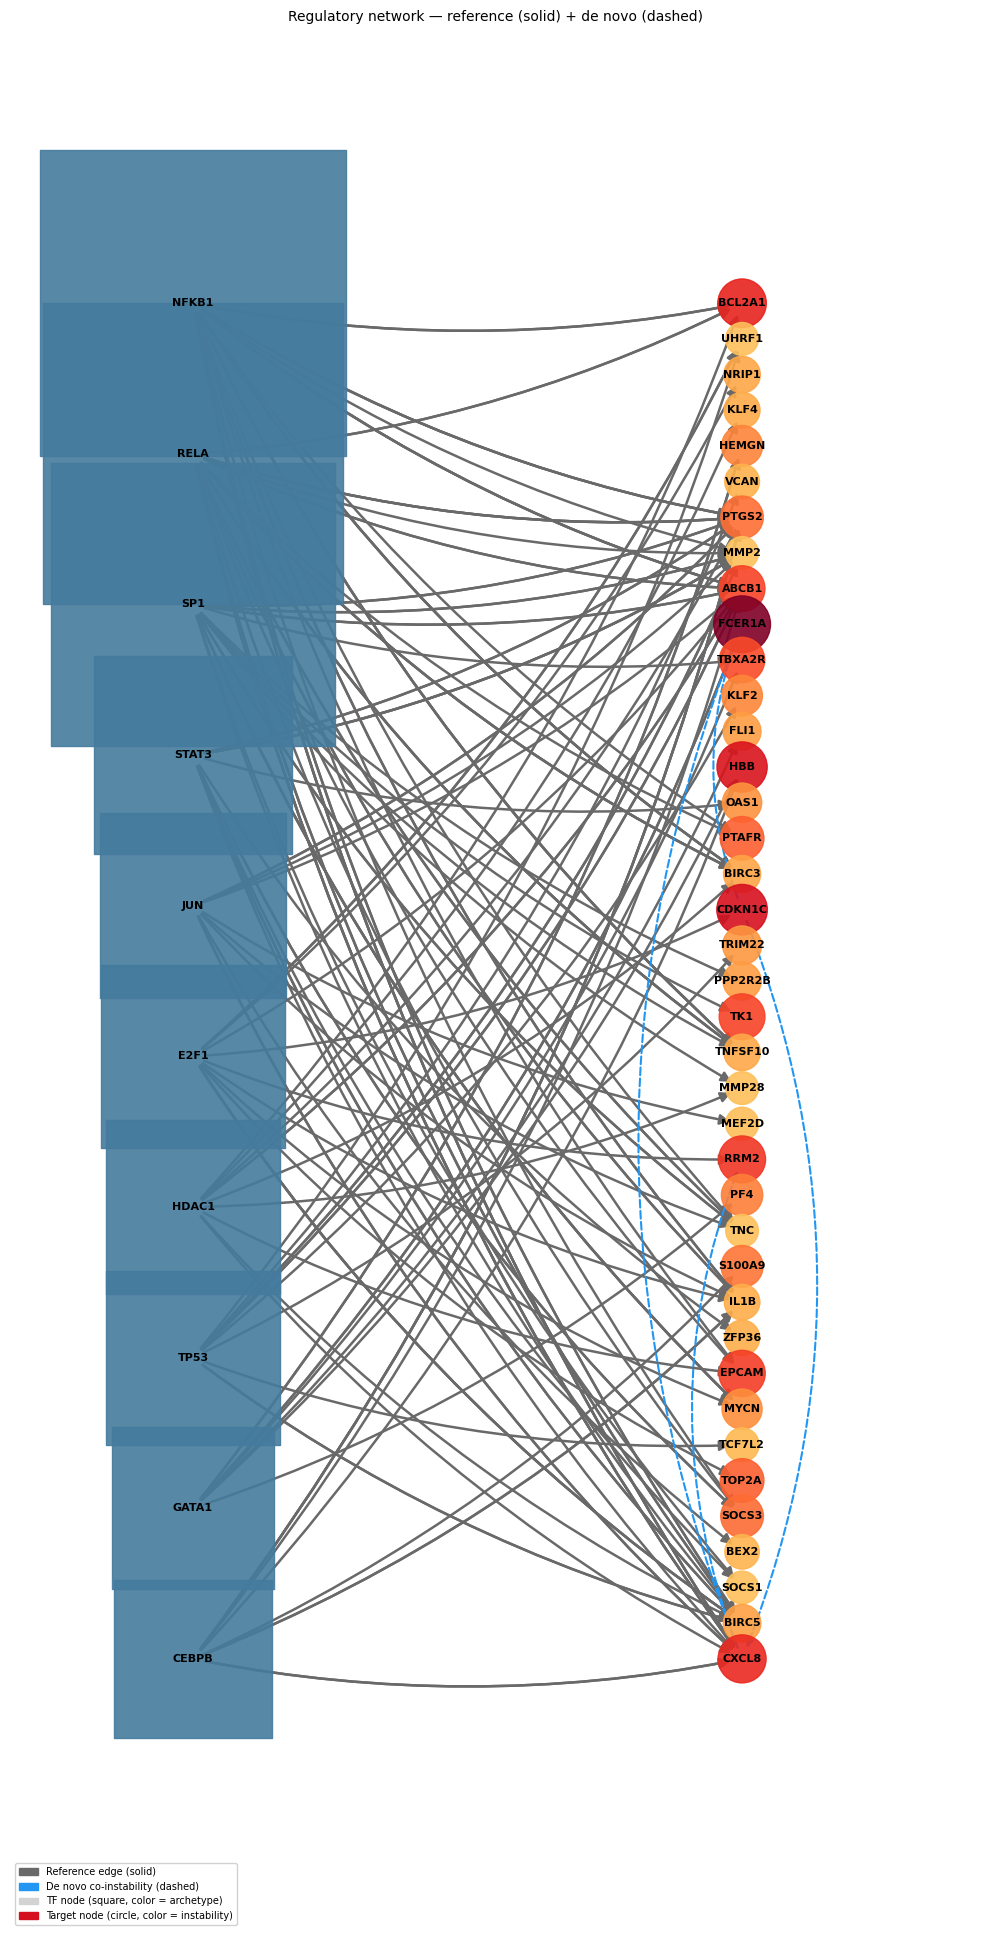


DC lineage — regulators
[network] TRRUST v2 loaded — 9,396 edges
Found 10 regulators
regulator  weighted_score
    NFKB1         18.8640
     RELA         18.1707
      SP1         16.6535
    STAT3          9.4200
      JUN          7.7121
     TP53          5.8257
    STAT1          5.2817
    HDAC1          5.1383
     E2F1          5.0176
     SPI1          4.7177


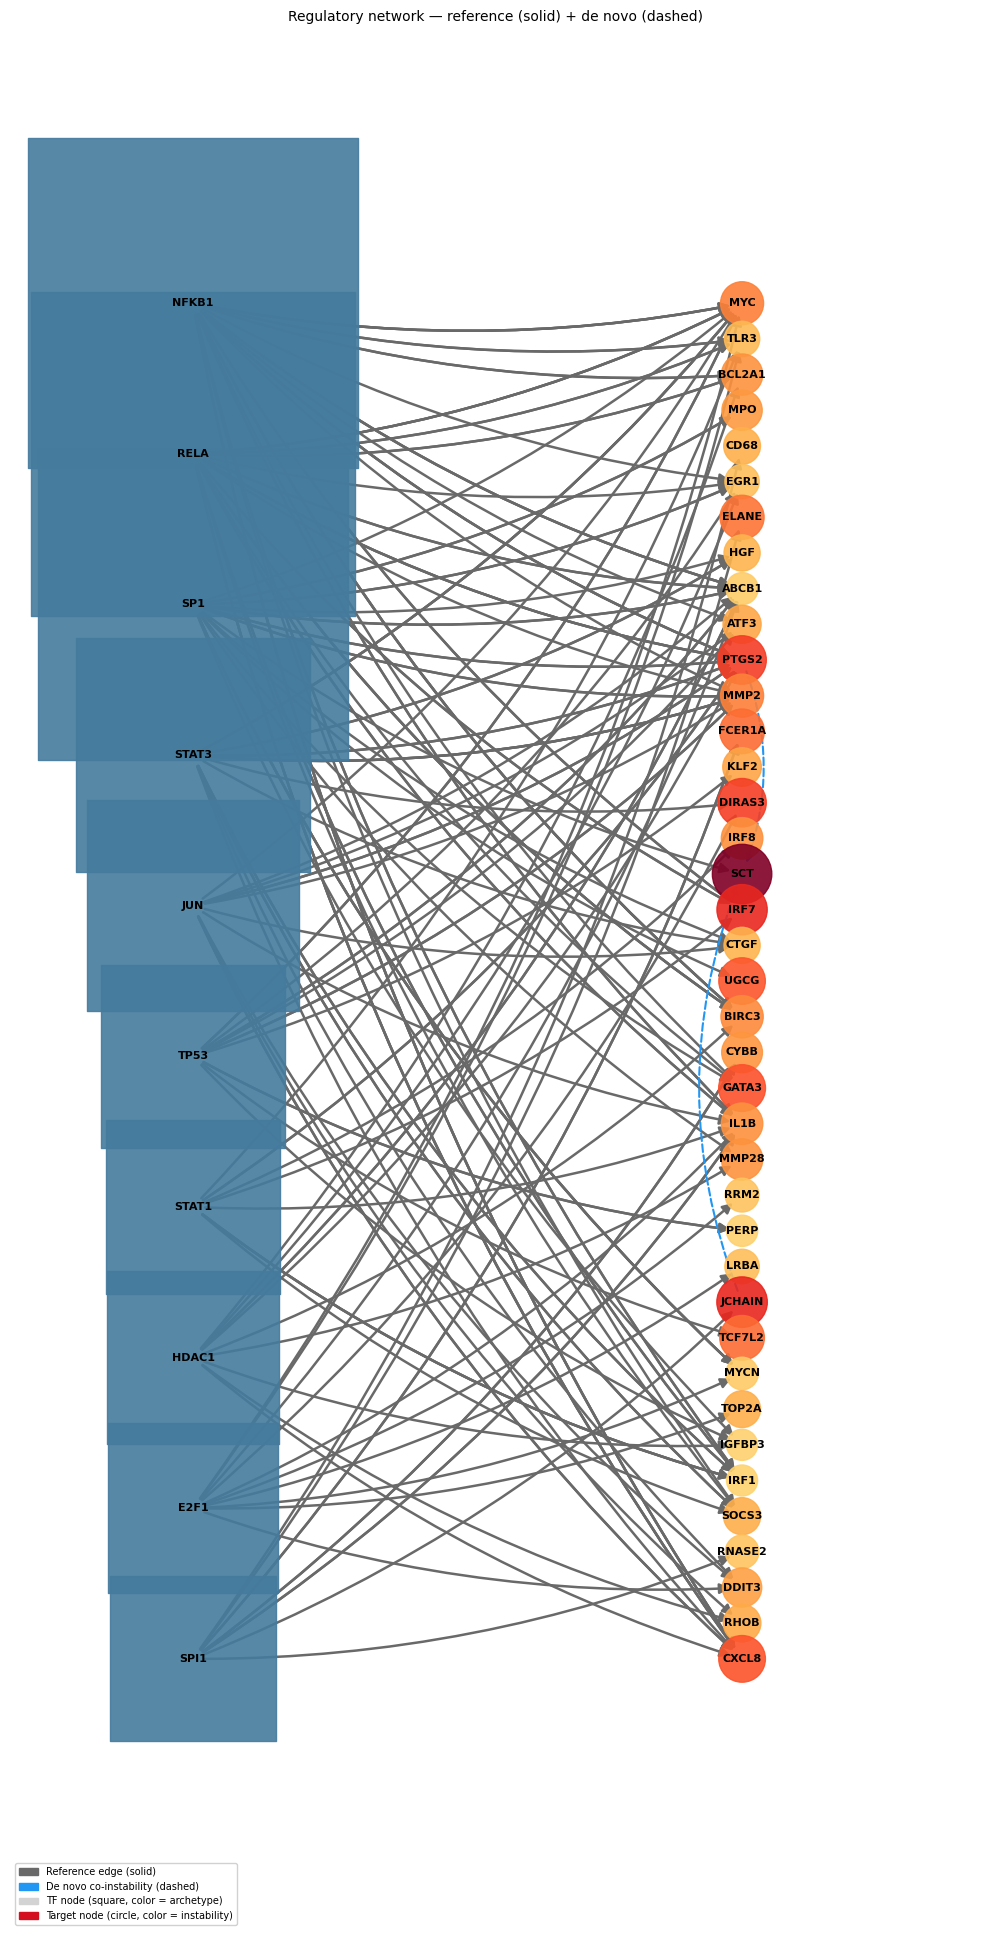


Mono lineage — regulators
[network] TRRUST v2 loaded — 9,396 edges
  [Mono] infer_regulators: No regulator results. Check that instability scores are computed.


In [20]:
reg_tables = {}

for branch in branch_models:
    key     = f'scjdo_{branch}'
    reg_key = f'scjdo_regulators_{branch}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    ad_b    = ad[cell_idx].copy()
    ad_b.uns[key] = ad.uns[key]
    if 'PCs' in ad.varm:
        ad_b.varm['PCs'] = ad.varm['PCs']

    # Human TRRUST uses uppercase gene symbols (MPO, KLF1, ELANE)
    # The bone marrow genes are already uppercase, but normalize to be safe.
    ad_b.var_names = ad_b.var_names.str.upper()

    print(f'\n{"="*55}')
    print(f'{branch} lineage — regulators')
    print(f'{"="*55}')

    try:
        df_reg = sjd.tl.infer_regulators(
            ad_b, key=key, organism='human',  # bone marrow = human data
            n_top=10, min_targets=2, key_added=reg_key, verbose=False,
        )
        print(f'Found {len(df_reg)} regulators')
        if len(df_reg):
            print(df_reg[['regulator', 'weighted_score']].head(10).to_string(index=False))
            sjd.pl.regulator_network(
                ad_b, key=reg_key, scjdo_key=key,
                n_tfs=10, n_targets=10,
                save=OUTDIR + f'regulator_network_{branch}.pdf',
            )
        else:
            print(f'  No regulators found for {branch}')
    except (ValueError, Exception) as e:
        print(f'  [{branch}] infer_regulators: {e}')
        df_reg = pd.DataFrame(columns=[
            'regulator', 'weighted_score', 'mean_instability',
            'enrichment_score', 'branch_specificity', 'peak_archetype',
            'db_confidence', 'n_targets', 'enrichment_pval', 'top_targets',
        ])

    reg_tables[branch] = df_reg
    df_reg.to_csv(OUTDIR + f'regulators_{branch}.csv', index=False)

## Step 7 — Cross-lineage comparison

Which instability genes and regulators are lineage-specific vs shared across DC, Mono, Ery?

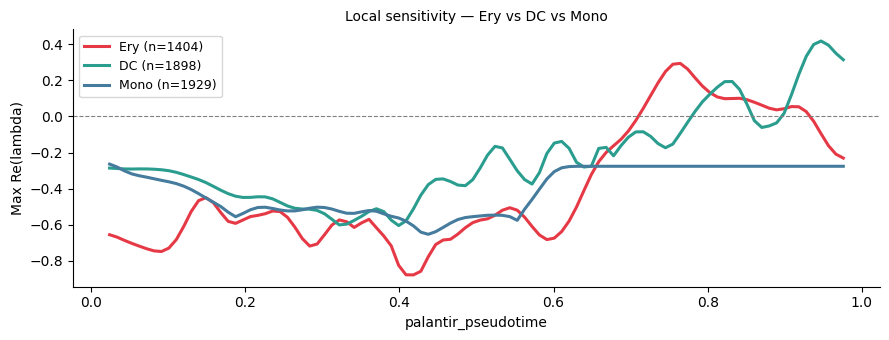


Instability gene overlap:
  Ery-specific (15): AC026188.1, AHSP, CDH9, CXCL3, DOK2, FCER1A, GPR141, NMU
  DC-specific (15): AC108938.5, DPYSL3, FCRLA, GZMB, IGKC, IGLC2, IGLC3, LILRA4
  Shared:          

Regulator overlap:


In [21]:
branches = list(branch_models.keys())

# ── Sensitivity profiles side-by-side ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))
for branch in branches:
    key = f'scjdo_{branch}'
    t   = ad.uns[key]['t_centers']
    eig = ad.uns[key]['max_real_eig']
    n   = ad.uns[key]['n_cells']
    ax.plot(t, eig, color=BRANCH_COLORS.get(branch,'#555'),
            lw=2.2, label=f'{branch} (n={n})')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('palantir_pseudotime'); ax.set_ylabel('Max Re(lambda)')
ax.set_title('Local sensitivity — Ery vs DC vs Mono', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTDIR + 'sensitivity_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Instability gene overlap ──────────────────────────────────────────────
print('\nInstability gene overlap:')
gene_sets = {b: set(gene_tables[b]['gene']) for b in branches
             if b in gene_tables and 'gene' in gene_tables[b].columns}
for b in gene_sets:
    others = [gene_sets[o] for o in gene_sets if o != b]
    unique = gene_sets[b] - set.union(*others) if others else gene_sets[b]
    uniq_str = ', '.join(sorted(unique)[:8])
    print(f'  {b}-specific ({len(unique)}): {uniq_str}')
if len(gene_sets) > 1:
    shared_str = ', '.join(sorted(set.intersection(*gene_sets.values()))[:8])
    print(f'  Shared:          {shared_str}')

# ── Regulator overlap ─────────────────────────────────────────────────────
print('\nRegulator overlap:')
reg_sets = {b: set(reg_tables[b]['regulator']) for b in branches
            if b in reg_tables and 'regulator' in reg_tables[b].columns}
for b in reg_sets:
    others = [reg_sets[o] for o in reg_sets if o != b]
    unique = reg_sets[b] - set.union(*others) if others else reg_sets[b]
    #print(f'  {b}-specific ({len(unique)}): {', '.join(sorted(unique)[:6])}')
if len(reg_sets) > 1:
    shared = set.intersection(*reg_sets.values())
    #print(f'  Shared ({len(shared)}): {', '.join(sorted(shared)[:6])}')

## Step 8 — Save annotated data

In [22]:
import json

# Summary table
rows = []
for branch in branch_models:
    key = f'scjdo_{branch}'
    res = ad.uns[key]
    rows.append({
        'branch':               branch,
        'n_cells':              res['n_cells'],
        'r2':                   round(float(res['r2']), 3),
        'peak_sensitivity_pt':  round(float(
            res['t_centers'][np.argmax(res['max_real_eig'])]), 3),
        'max_sensitivity':      round(float(res['max_real_eig'].max()), 4),
        'top_instab_gene':      (res['top_instability_genes'][0]
                                 if res.get('top_instability_genes') else ''),
        'top_regulator':        (reg_tables[branch]['regulator'].iloc[0]
                                 if branch in reg_tables and len(reg_tables[branch]) > 0 else ''),
    })

summary = pd.DataFrame(rows)
summary.to_csv(OUTDIR + 'branch_summary.csv', index=False)
print('Branch summary:')
print(summary.to_string(index=False))

# Save processed AnnData with all scJDO results
ad.write_h5ad(OUTDIR + 'marrow_scjdo.h5ad')
print(f'\nSaved: {OUTDIR}marrow_scjdo.h5ad')
print(f'\nAll outputs in: {OUTDIR}')
import pathlib
for f in sorted(pathlib.Path(OUTDIR).iterdir()):
    print(f'  {f.name}')

Branch summary:
branch  n_cells    r2  peak_sensitivity_pt  max_sensitivity top_instab_gene top_regulator
   Ery     1404 0.983                0.764           0.2938             NMU         NFKB1
    DC     1898 0.976                0.947           0.4176             SCT         NFKB1
  Mono     1929 0.998                0.024          -0.2638                              

Saved: results/palantir_driftfield_ldvae/marrow_scjdo.h5ad

All outputs in: results/palantir_driftfield_ldvae/
  branch_selection.pdf
  branch_summary.csv
  figure_DC.pdf
  figure_Ery.pdf
  figure_Mono.pdf
  instability_genes_DC.csv
  instability_genes_DC.pdf
  instability_genes_Ery.csv
  instability_genes_Ery.pdf
  instability_genes_Mono.csv
  instability_genes_Mono.pdf
  marrow_scjdo.h5ad
  palantir_results.pdf
  regulator_network_DC.pdf
  regulator_network_Ery.pdf
  regulators_DC.csv
  regulators_Ery.csv
  regulators_Mono.csv
  sensitivity_comparison.pdf
  trajectories.pdf
  trajectory_DC.pdf
  trajectory_Ery.pdf